# LinUCB — Contextual Bandit for Discount Selection

**Disjoint LinUCB** (Li et al. 2010):  
`score(a, x) = θ̂_a · x  +  α √(x⊤ A_a⁻¹ x)`

**Context `x`**: listing-level features observable *before* choosing a discount —  
quality signals (rating, reviews), demand signals (days_until, is_weekend),  
and property type (accommodates, instant_bookable).  

The hypothesis: price-sensitive guests (budget properties, far-ahead bookings)  
respond better to discounts, while premium/luxury properties may gain from surcharges.  
LinUCB learns these interactions within each 5 000-step round.  

Same arm definitions as 06_mab.ipynb: −15% −10% 0% +10% +15%.  
Each of 30 rounds is independent (agent resets) for statistical testing.

## 1. Imports & Configuration

In [148]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, warnings
warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data',    'processed_data.csv')
MODEL_PATH = os.path.join(BASE_DIR, 'model',   'xgboost_model.pkl')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

N_ROUNDS       = 30
N_TRANSACTIONS = 50_000
SEED_BASE      = 42

ARM_DISCOUNTS  = np.array([0.90, 0.95, 1.00, 1.05, 1.10])
ARM_LABELS     = ['-10%', '-5%', '0%', '+5%', '+10%']
N_ARMS        = len(ARM_DISCOUNTS)
BASELINE_ARM  = 2
ARM_COLORS    = ['#2166AC', '#74ADD1', '#888888', '#F46D43', '#D73027']

# Context features: observable before discount decision
CONTEXT_FEATURES = [
    'neighbourhood_group_cleansed',   # quality → affects price sensitivity
    'accommodates',           # group size → larger groups more price-sensitive
    'is_weekend',             # demand level    
    'number_of_reviews',      # listing maturity
]
# Encoded: bias(1) + 6 normalised features = 7 dimensions
CONTEXT_DIM = len(CONTEXT_FEATURES) + 1

print(f'Context features ({CONTEXT_DIM}D): {CONTEXT_FEATURES}')

Context features (5D): ['neighbourhood_group_cleansed', 'accommodates', 'is_weekend', 'number_of_reviews']


## 2. Load Model & Precompute Arm Rewards

In [149]:
saved    = joblib.load(MODEL_PATH)
model    = saved['model']
features = saved['features']

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.dropna(subset=['price_tier', 'price_listing']).copy()
df['price_tier'] = df['price_tier'].astype(int)
n_rows = len(df)
print(f'Data loaded: {df.shape}')

def compute_tier(prices):
    t = np.zeros(len(prices), dtype=int)
    t[(prices > 100) & (prices <= 300)] = 1
    t[(prices > 300) & (prices <= 600)] = 2
    t[prices > 600] = 3
    return t

print('Pre-computing rewards for each discount arm...')
arm_rewards = np.zeros((N_ARMS, n_rows))
arm_probs   = np.zeros((N_ARMS, n_rows))

for a, discount in enumerate(ARM_DISCOUNTS):
    df_mod = df[features].copy()
    new_prices = df['price_listing'].values * discount
    if 'price_listing' in features:
        df_mod['price_listing'] = new_prices
    # price_tier intentionally NOT updated — original listing category is preserved
    probs = model.predict_proba(df_mod)[:, 1]
    arm_rewards[a] = probs * new_prices
    arm_probs[a]   = probs
    print(f'  Arm {a} ({ARM_LABELS[a]:>4s}, x{discount})  '
          f'mean_P={probs.mean():.4f}  '
          f'mean_reward={arm_rewards[a].mean():.2f}')

print('Best arm (unconstrained):', ARM_LABELS[int(np.argmax(arm_rewards.mean(axis=1)))])

# ── Constrained MAB: booking-volume constraint ──────────────────────────────
# Zero-out arm_rewards[a, i] where arm a's booking probability falls below
# VOLUME_THRESHOLD × baseline probability at listing i.
# Rationale: to satisfy both guests and hosts on the two-sided platform,
# the chosen pricing arm must not reduce booking volume by more than 2%
# relative to the no-discount baseline at each individual listing.
VOLUME_THRESHOLD = 0.60
baseline_probs   = arm_probs[BASELINE_ARM]          # shape: (n_rows,)
print(f'\nApplying booking-volume constraint (threshold = {VOLUME_THRESHOLD:.0%} of baseline P)...')
for a in range(N_ARMS):
    mask = arm_probs[a] < VOLUME_THRESHOLD * baseline_probs
    arm_rewards[a, mask] = 0.0
    print(f'  Arm {a} ({ARM_LABELS[a]:>4s}): {mask.sum():>8,} / {n_rows:,} listings constrained  ({mask.mean()*100:.1f}%)')
print('Best arm (after constraint):', ARM_LABELS[int(np.argmax(arm_rewards.mean(axis=1)))])


# Load baseline for reference plots
baseline_df = pd.read_csv(os.path.join(RESULT_DIR, 'baseline_results.csv'))
baseline_wc = np.load(os.path.join(RESULT_DIR, 'baseline_within_round.npy'))

# ── Stratified tier pools — matching 05_baseline.ipynb ─────────────────────
N_TIERS = 4
tier_vals         = df['price_tier'].values
tier_pool_indices = {t: np.where(tier_vals == t)[0] for t in range(N_TIERS)}
tier_props = {t: len(v) / n_rows for t, v in tier_pool_indices.items()}
tier_ns    = {t: int(np.floor(tier_props[t] * N_TRANSACTIONS)) for t in range(N_TIERS)}
tier_ns[max(tier_props, key=tier_props.get)] += N_TRANSACTIONS - sum(tier_ns.values())
print('Tier sample counts per round:', {t: tier_ns[t] for t in range(N_TIERS)})


def sample_round_indices(round_idx):
    """
    Stratified-by-tier sampling matching 05_baseline.ipynb exactly.
    Each tier uses a fresh np.random.RandomState(SEED_BASE + round_idx),
    mirroring pandas sample(random_state=seed) used in 05.
    """
    seed = SEED_BASE + round_idx
    idx_list = []
    for t in range(N_TIERS):
        rs   = np.random.RandomState(seed)
        pool = tier_pool_indices[t]
        idx_list.extend(pool[rs.choice(len(pool), size=tier_ns[t], replace=True)])
    idx_array = np.array(idx_list)
    np.random.RandomState(seed + 9999).shuffle(idx_array)  # break tier ordering
    return idx_array

Data loaded: (953380, 15)
Pre-computing rewards for each discount arm...
  Arm 0 (-10%, x0.9)  mean_P=0.3431  mean_reward=83.10
  Arm 1 ( -5%, x0.95)  mean_P=0.3376  mean_reward=86.80
  Arm 2 (  0%, x1.0)  mean_P=0.3342  mean_reward=90.12
  Arm 3 ( +5%, x1.05)  mean_P=0.3339  mean_reward=94.57
  Arm 4 (+10%, x1.1)  mean_P=0.3353  mean_reward=99.18
Best arm (unconstrained): +10%

Applying booking-volume constraint (threshold = 60% of baseline P)...
  Arm 0 (-10%):  122,159 / 953,380 listings constrained  (12.8%)
  Arm 1 ( -5%):   87,953 / 953,380 listings constrained  (9.2%)
  Arm 2 (  0%):        0 / 953,380 listings constrained  (0.0%)
  Arm 3 ( +5%):   69,686 / 953,380 listings constrained  (7.3%)
  Arm 4 (+10%):  110,176 / 953,380 listings constrained  (11.6%)
Best arm (after constraint): +10%
Tier sample counts per round: {0: 13878, 1: 19411, 2: 12404, 3: 4307}


## 3. Context Encoding

In [150]:
# Normalisation constants derived from data (computed once, fixed for comparability)
NORM = {
    # neighbourhood_group_cleansed: label-encoded int, normalise to [0, 1] by max value
    'neighbourhood_group_cleansed': (0.0, float(df['neighbourhood_group_cleansed'].max())),
    'accommodates':                 (1.0, float(df['accommodates'].max())),
    'is_weekend':                   (0.0, 1.0),
    'number_of_reviews':            (0.0, float(df['number_of_reviews'].quantile(0.95))),
}

def encode_context(df_rows):
    """
    Encode listing features into a (n, CONTEXT_DIM) context matrix.
    dim 0: bias = 1.0
    dims 1-4: normalised features from CONTEXT_FEATURES
    """
    if isinstance(df_rows, pd.Series):
        df_rows = df_rows.to_frame().T
    n = len(df_rows)
    x = np.zeros((n, CONTEXT_DIM))
    x[:, 0] = 1.0
    for i, feat in enumerate(CONTEXT_FEATURES):
        loc, scale = NORM[feat]
        raw = df_rows[feat].fillna(loc).values.astype(float)
        x[:, i + 1] = np.clip((raw - loc) / max(scale, 1e-9), 0, 1)
    return x


# Pre-build context matrix for all rows (fast lookup during simulation)
print('Building context matrix...')
context_matrix = encode_context(df)   # shape: (n_rows, CONTEXT_DIM)
print(f'context_matrix shape: {context_matrix.shape}')
print(f'Sample row 0: {context_matrix[0].round(3)}')

Building context matrix...
context_matrix shape: (953380, 5)
Sample row 0: [1.    0.    0.    1.    0.093]


## 4. LinUCB Agent

In [151]:
class LinUCB:
    """
    Disjoint LinUCB (Li et al. 2010).

    Per-arm parameters:
      A_a (d×d): regularised feature covariance  (init = I)
      b_a (d,) : reward-weighted feature sum
    Estimate: θ̂_a = A_a⁻¹ b_a
    Score:    θ̂_a · x  +  alpha * sqrt(x⊤ A_a⁻¹ x)

    reward_scale normalises GMV rewards so that θ̂_a · x and the UCB
    exploration term alpha*sqrt(x⊤ A⁻¹ x) are on the same scale.
    Without normalisation, the exploitation term dominates by ~70x and
    LinUCB never explores properly.

    reset() reinitialises for each independent round.
    """
    def __init__(self, n_arms=N_ARMS, d=CONTEXT_DIM, alpha=1.0, reward_scale=1.0):
        self.n_arms       = n_arms
        self.d            = d
        self.alpha        = alpha
        self.reward_scale = reward_scale   # e.g. arm_rewards.max()
        self.reset()

    def reset(self):
        self.A = [np.eye(self.d) for _ in range(self.n_arms)]
        self.b = [np.zeros(self.d) for _ in range(self.n_arms)]
        self.N = np.zeros(self.n_arms, dtype=int)

    def select_arm(self, x):
        scores = np.zeros(self.n_arms)
        for a in range(self.n_arms):
            A_inv     = np.linalg.inv(self.A[a])
            theta_hat = A_inv @ self.b[a]
            scores[a] = theta_hat @ x + self.alpha * np.sqrt(x @ A_inv @ x)
        return int(np.argmax(scores))

    def update(self, arm, x, reward):
        r_norm = reward / self.reward_scale   # normalise to [0,1]
        self.A[arm] += np.outer(x, x)
        self.b[arm] += r_norm * x
        self.N[arm] += 1

    def get_theta(self, arm):
        return np.linalg.solve(self.A[arm], self.b[arm])

    def get_ucb_width(self, arm, x):
        return self.alpha * np.sqrt(x @ np.linalg.inv(self.A[arm]) @ x)

    def name(self): return 'linucb'

## 5. Simulation Loop

In [152]:
def run_linucb_simulation(agent, arm_rewards, context_matrix,
                          n_rounds=N_ROUNDS, n_transactions=N_TRANSACTIONS):
    """
    At each step:
      1. Get row idx from pre-sampled stratified indices (matches 05_baseline.ipynb)
      2. Extract context x from context_matrix[idx]
      3. agent.select_arm(x) using LinUCB score (context-aware)
      4. reward = arm_rewards[arm, idx]  (pre-computed)
      5. agent.update(arm, x, reward)
    """
    records           = []
    within_cumulative = np.zeros((n_rounds, n_transactions))
    arm_history       = np.zeros((n_rounds, n_transactions), dtype=np.int8)
    ref_x             = context_matrix[0]   # fixed reference context for UCB-width tracking

    for r in range(n_rounds):
        agent.reset()
        round_indices = sample_round_indices(r)      # stratified, same as 05 & 06
        arm_counts = np.zeros(N_ARMS, dtype=int)
        arm_totals = np.zeros(N_ARMS)
        cumulative = 0.0

        for step in range(n_transactions):
            idx    = int(round_indices[step])
            x      = context_matrix[idx]
            arm    = agent.select_arm(x)
            reward = float(arm_rewards[arm, idx])
            agent.update(arm, x, reward)
            arm_counts[arm]  += 1
            arm_totals[arm]  += reward
            cumulative       += reward
            within_cumulative[r, step] = cumulative
            arm_history[r, step]       = arm

        rec = {'round': r + 1, 'total_reward': cumulative}
        for a in range(N_ARMS):
            rec[f'n_arm_{a}']      = int(arm_counts[a])
            rec[f'reward_arm_{a}'] = float(arm_totals[a])
            rec[f'theta_norm_{a}'] = float(np.linalg.norm(agent.get_theta(a)))
            rec[f'ucb_width_{a}']  = float(agent.get_ucb_width(a, ref_x))
        records.append(rec)

        print(f'Round {r+1:2d}/30  reward={cumulative:>9,.0f}  '
              f'counts={arm_counts.tolist()}')

    return pd.DataFrame(records), within_cumulative, arm_history


np.random.seed(SEED_BASE + 40)
agent   = LinUCB(alpha=1.0, reward_scale=float(arm_rewards.max()))
results, within_cumulative, arm_history = run_linucb_simulation(
    agent, arm_rewards, context_matrix
)
print(f'\nLinUCB mean reward/round: {results["total_reward"].mean():,.0f}')

Round  1/30  reward=4,482,479  counts=[4014, 4386, 5263, 29910, 6427]
Round  2/30  reward=4,668,572  counts=[3464, 4760, 4981, 4410, 32385]
Round  3/30  reward=4,690,309  counts=[3554, 3960, 6049, 5630, 30807]
Round  4/30  reward=4,614,141  counts=[4391, 4917, 4727, 6455, 29510]
Round  5/30  reward=4,414,199  counts=[4264, 4572, 29478, 5360, 6326]
Round  6/30  reward=4,648,390  counts=[3526, 3489, 6276, 5770, 30939]
Round  7/30  reward=4,633,464  counts=[4041, 3324, 4978, 6107, 31550]
Round  8/30  reward=4,530,138  counts=[3701, 3984, 5452, 28932, 7931]
Round  9/30  reward=4,522,483  counts=[3663, 4917, 4923, 30771, 5726]
Round 10/30  reward=4,675,137  counts=[3832, 3885, 5325, 7309, 29649]
Round 11/30  reward=4,529,584  counts=[3969, 4412, 7509, 29503, 4607]
Round 12/30  reward=4,715,423  counts=[3651, 4102, 5052, 6785, 30410]
Round 13/30  reward=4,552,775  counts=[4925, 3731, 6025, 30597, 4722]
Round 14/30  reward=4,534,381  counts=[4257, 5146, 5163, 30109, 5325]
Round 15/30  reward=

## 6. Results & Visualisation

In [153]:
b_mean = baseline_df['total_reward'].mean()
print(f'Baseline mean reward/round : {b_mean:>12,.0f}')
print(f'LinUCB  mean reward/round  : {results["total_reward"].mean():>12,.0f}')
print(f'Improvement vs baseline    : {(results["total_reward"].mean()-b_mean)/b_mean*100:>+.2f}%')

Baseline mean reward/round :    4,511,037
LinUCB  mean reward/round  :    4,593,053
Improvement vs baseline    : +1.82%


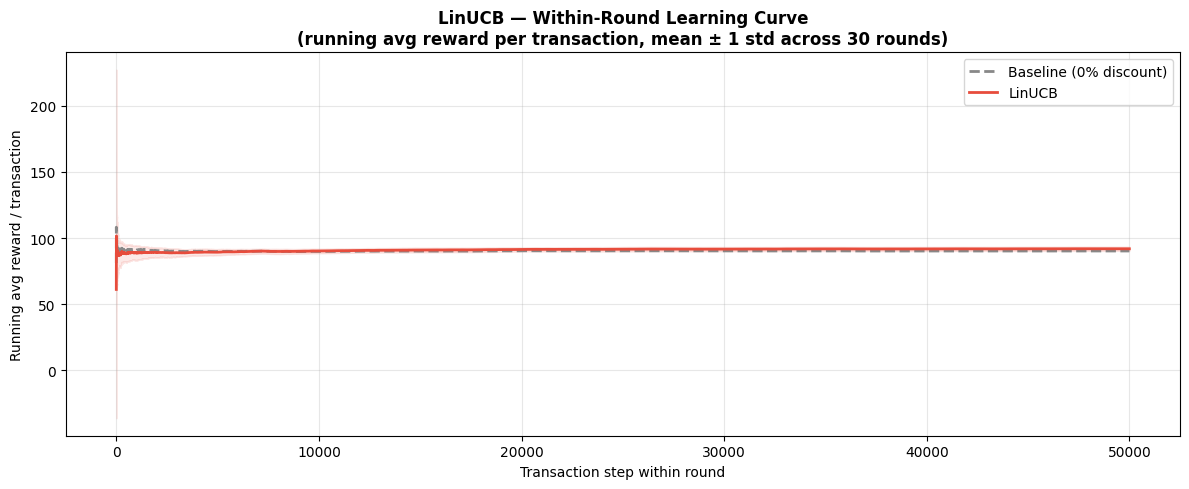

In [154]:
# ── Within-round learning curve: LinUCB vs baseline ────────────────────
steps = np.arange(1, N_TRANSACTIONS + 1)

fig, ax = plt.subplots(figsize=(12, 5))
for label, wc, color, ls in [
    ('Baseline (0% discount)', baseline_wc, '#888888', '--'),
    ('LinUCB',                 within_cumulative, '#E74C3C', '-'),
]:
    ra   = wc / steps[np.newaxis, :]
    mean = ra.mean(axis=0)
    std  = ra.std(axis=0)
    ax.plot(steps, mean, color=color, linestyle=ls, linewidth=2, label=label)
    if ls == '-':
        ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.12)

ax.set_title('LinUCB — Within-Round Learning Curve\n'
             '(running avg reward per transaction, mean ± 1 std across 30 rounds)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction step within round')
ax.set_ylabel('Running avg reward / transaction')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'linucb_learning_curve.png'), dpi=120)
plt.show()

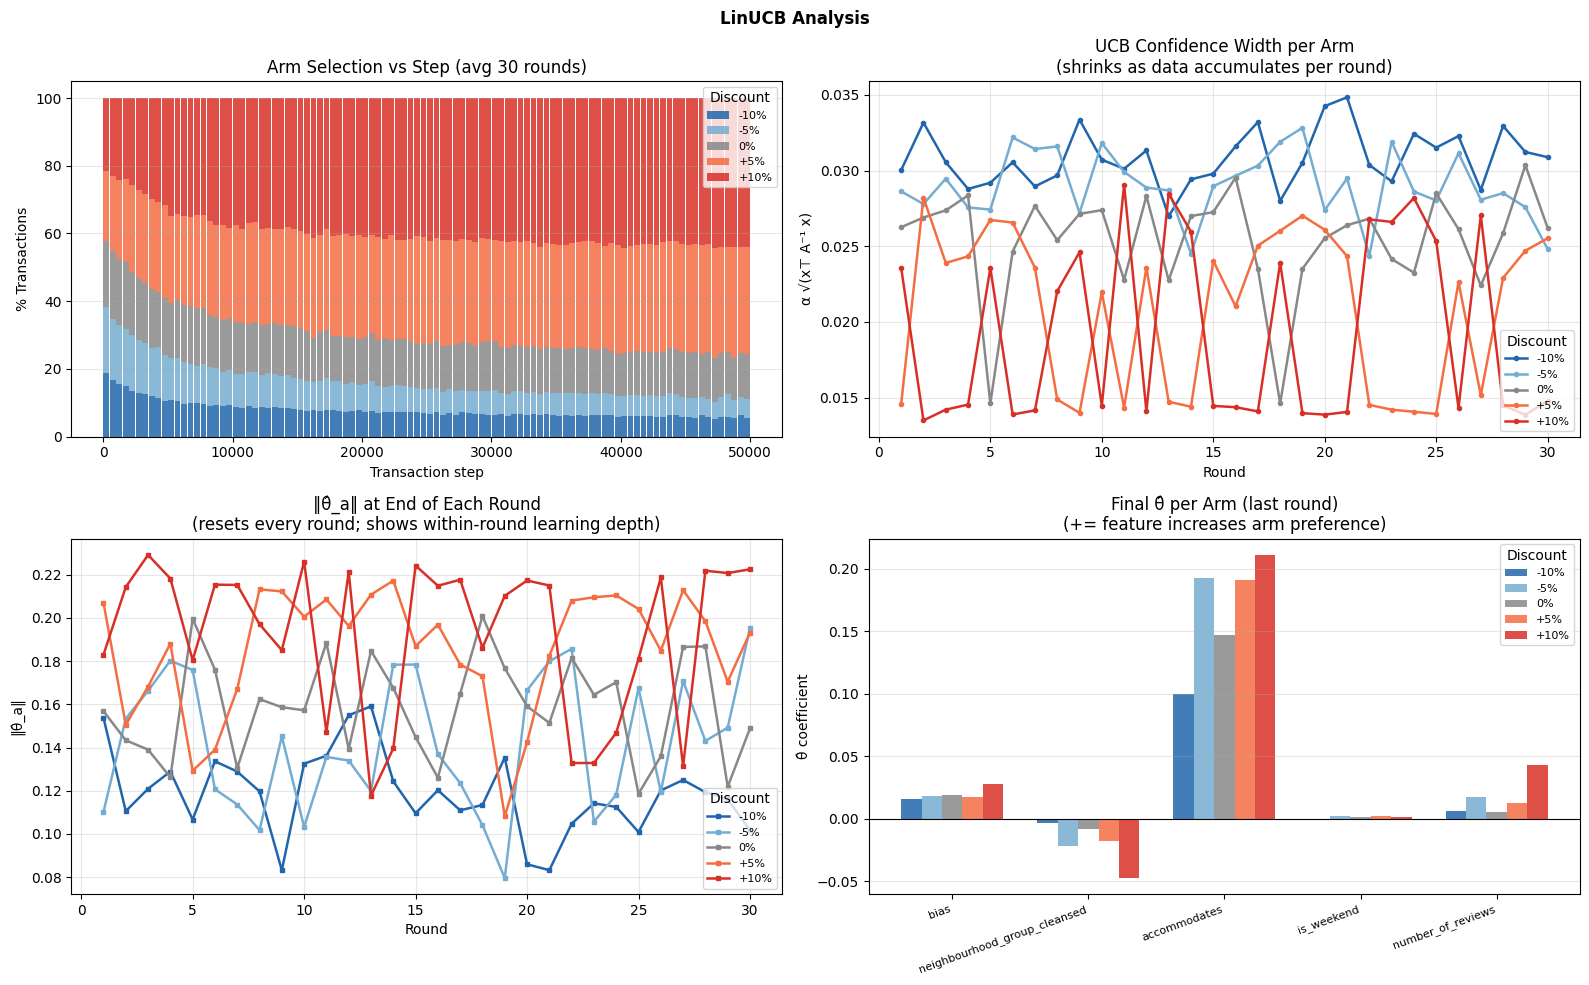

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LinUCB Analysis', fontsize=12, fontweight='bold')

# ── (1) Arm selection evolution (binned, avg across 30 rounds) ────────
ax = axes[0, 0]
BIN = 500
n_bins   = N_TRANSACTIONS // BIN
bin_mids = (np.arange(n_bins) + 0.5) * BIN
bottom   = np.zeros(n_bins)
for a in range(N_ARMS):
    prop = np.array([
        (arm_history[:, b*BIN:(b+1)*BIN] == a).mean()
        for b in range(n_bins)
    ])
    ax.bar(bin_mids, prop * 100, bottom=bottom, width=BIN * 0.9,
           color=ARM_COLORS[a], label=ARM_LABELS[a], alpha=0.85)
    bottom += prop * 100
ax.set_title('Arm Selection vs Step (avg 30 rounds)')
ax.set_xlabel('Transaction step')
ax.set_ylabel('% Transactions')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3, axis='y')

# ── (2) UCB confidence width shrinkage (end of each round) ───────────
ax = axes[0, 1]
for a in range(N_ARMS):
    ax.plot(results['round'], results[f'ucb_width_{a}'],
            color=ARM_COLORS[a], linewidth=1.8, marker='o', markersize=3,
            label=ARM_LABELS[a])
ax.set_title('UCB Confidence Width per Arm\n(shrinks as data accumulates per round)')
ax.set_xlabel('Round')
ax.set_ylabel('α √(x⊤ A⁻¹ x)')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3)

# ── (3) θ norm convergence per arm across rounds ──────────────────────
ax = axes[1, 0]
for a in range(N_ARMS):
    ax.plot(results['round'], results[f'theta_norm_{a}'],
            color=ARM_COLORS[a], linewidth=1.8, marker='s', markersize=3,
            label=ARM_LABELS[a])
ax.set_title('‖θ̂_a‖ at End of Each Round\n(resets every round; shows within-round learning depth)')
ax.set_xlabel('Round')
ax.set_ylabel('‖θ̂_a‖')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3)

# ── (4) Final θ: what did LinUCB learn about each context feature? ────
ax = axes[1, 1]
dim_labels = ['bias'] + CONTEXT_FEATURES
x_pos = np.arange(CONTEXT_DIM)
w     = 0.15
for a in range(N_ARMS):
    theta = agent.get_theta(a)   # final round's theta
    ax.bar(x_pos + a * w, theta, w, color=ARM_COLORS[a], label=ARM_LABELS[a], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Final θ̂ per Arm (last round)\n(+= feature increases arm preference)')
ax.set_xticks(x_pos + w * (N_ARMS - 1) / 2)
ax.set_xticklabels(dim_labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('θ̂ coefficient')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'linucb_analysis.png'), dpi=120)
plt.show()

## 7. Save Results

In [156]:
results.to_csv(os.path.join(RESULT_DIR, 'linucb_results.csv'), index=False)
np.save(os.path.join(RESULT_DIR, 'linucb_within_round.npy'), within_cumulative)
np.save(os.path.join(RESULT_DIR, 'linucb_arm_history.npy'), arm_history)
print('Saved: linucb_results.csv  +  linucb_within_round.npy  +  linucb_arm_history.npy')

Saved: linucb_results.csv  +  linucb_within_round.npy  +  linucb_arm_history.npy
